# Semana 2: GCN para Recomendación de Tweets

**Dataset:** Twitter15/16 (rumores y fake news)  
**Objetivo:** Implementar un modelo GCN baseline y analizar su impacto en la propagación de desinformación

En este notebook vamos a entrenar un Graph Convolutional Network (GCN) sobre el grafo bipartito user-item que construimos la semana pasada. La idea es ver cómo los embeddings semánticos (BERT) comparan contra embeddings random y cómo cada versión afecta la propagación de fake news.

## Descarga de datos desde GitHub

Descargamos los archivos procesados y los grafos directo desde el repo. Esto funciona tanto en Colab como en local.

In [ ]:
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_h1/train_interactions_idx.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_h1/test_interactions_idx.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_h1/item_labels.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs/bipartite_graph.pt
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs/social_graph.pt
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs/item_embeddings_bert.pt
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/midterm/graphs/item_embeddings_random.pt

print("Archivos descargados ✓")

Archivos descargados ✓


## Instalación de dependencias

Instalamos PyTorch Geometric y las demás librerías necesarias. Esto puede tomar un par de minutos en Colab.

In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q sentence-transformers

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Fijar seeds para reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

PyTorch version: 2.8.0+cu126
CUDA available: True


## Carga de datos y grafos

Cargamos todo lo que descargamos: el grafo bipartito, los embeddings de BERT y random, las interacciones de train/test y los labels de los tweets.

In [ ]:
# Cargar grafos
print("Cargando grafos...")
bipartite_graph = torch.load('bipartite_graph.pt', weights_only=False)
social_graph = torch.load('social_graph.pt', weights_only=False)

# Cargar embeddings
print("Cargando embeddings...")
item_embeddings_bert = torch.load('item_embeddings_bert.pt', weights_only=False)
item_embeddings_random = torch.load('item_embeddings_random.pt', weights_only=False)

# Cargar datos tabulares
print("Cargando datasets...")
train_df = pd.read_csv('train_interactions_idx.csv')
test_df = pd.read_csv('test_interactions_idx.csv')
labels_df = pd.read_csv('item_labels.csv')

num_users = bipartite_graph['num_users']
num_items = bipartite_graph['num_items']
edge_index = bipartite_graph['edge_index']  # Este es el grafo completo (no lo usaremos para train)

# Crear edge_index solo con train interactions
print("\nCreando grafo de entrenamiento (solo train edges)...")
train_edges = []
for _, row in train_df.iterrows():
    u, i = row['user_idx'], row['item_idx']
    # Edge user → item
    train_edges.append([u, num_users + i])
    # Edge item → user (bidireccional para GCN)
    train_edges.append([num_users + i, u])

train_edge_index = torch.LongTensor(train_edges).t().contiguous()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_edge_index = train_edge_index.to(device)

print(f"\nEstadísticas:")
print(f"  Users: {num_users}")
print(f"  Items: {num_items}")
print(f"  Original bipartite edges: {edge_index.shape[1]}")
print(f"  Train-only edges: {train_edge_index.shape[1]}")
print(f"  Test edges: {len(test_df)}")
print(f"  BERT embedding dim: {item_embeddings_bert.shape[1]}")
print(f"  Random embedding dim: {item_embeddings_random.shape[1]}")

Cargando grafos...
Cargando embeddings...
Cargando datasets...

Creando grafo de entrenamiento (solo train edges)...

Estadísticas:
  Users: 4856
  Items: 2308
  Original bipartite edges: 117988
  Train-only edges: 117988
  Test edges: 4856
  BERT embedding dim: 384
  Random embedding dim: 64


## Implementación del modelo GCN

Acá viene el modelo. Básicamente es un GCN de 2 capas que toma los embeddings de users e items, los pasa por el grafo bipartito y aprende representaciones mejores para hacer recomendaciones.

La arquitectura:
- Users: embeddings aprendibles
- Items: proyectamos los features (BERT o random) a la misma dimensión que users
- 2 capas GCN con ReLU en el medio
- Output: embeddings finales para calcular scores user-item

In [ ]:
class GCNRecommender(nn.Module):
    def __init__(self, num_users, num_items, item_feature_dim,
                 embedding_dim=64, hidden_dim=32):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim

        # Embeddings de usuarios (aprendibles desde cero)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)

        # Proyección de features de items a embedding_dim
        self.item_projection = nn.Linear(item_feature_dim, embedding_dim)

        # Capas GCN
        self.conv1 = GCNConv(embedding_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, embedding_dim)

        # Inicialización Xavier (mejora convergencia)
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_projection.weight)

    def forward(self, edge_index, item_features):
        # Obtener embeddings iniciales
        user_emb = self.user_embedding.weight  # [num_users, emb_dim]
        item_emb = self.item_projection(item_features)  # [num_items, emb_dim]

        # Concatenar users e items en un solo tensor para el grafo bipartito
        x = torch.cat([user_emb, item_emb], dim=0)  # [num_users+num_items, emb_dim]

        # Pasar por las capas GCN
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        # Separar users e items de vuelta
        user_emb_final = x[:self.num_users]
        item_emb_final = x[self.num_users:]

        return user_emb_final, item_emb_final

    def predict(self, user_emb, item_emb, user_idx):
        """Calcula scores de un usuario con todos los items"""
        user_vec = user_emb[user_idx]  # [emb_dim]
        scores = torch.matmul(user_vec, item_emb.t())  # [num_items]
        return scores

print("Modelo GCN definido correctamente ✓")

Modelo GCN definido correctamente ✓


## Función de entrenamiento (BPR Loss)

Usamos Bayesian Personalized Ranking (BPR), que es el estándar para recomendación. La idea es que para cada interacción positiva (user-item que sí ocurrió), sampleamos un item negativo random y forzamos a que el score del positivo sea mayor que el del negativo.

Loss: `-log(sigmoid(score_pos - score_neg))`

In [ ]:
def train_epoch(model, edge_index, item_features, train_interactions, optimizer, device):
    model.train()
    optimizer.zero_grad()

    user_emb, item_emb = model(edge_index, item_features)

    # Crear dict de items por usuario
    user_items_dict = train_interactions.groupby('user_idx')['item_idx'].apply(set).to_dict()

    pos_users = torch.LongTensor(train_interactions['user_idx'].values).to(device)
    pos_items = torch.LongTensor(train_interactions['item_idx'].values).to(device)

    # Negative sampling correcto
    neg_items_list = []
    for user_idx in pos_users.cpu().numpy():
        consumed = user_items_dict.get(user_idx, set())
        # Samplear de items NO consumidos
        available = list(set(range(model.num_items)) - consumed)
        if available:
            neg_items_list.append(random.choice(available))
        else:
            neg_items_list.append(random.randint(0, model.num_items-1))

    neg_items = torch.LongTensor(neg_items_list).to(device)

    pos_scores = (user_emb[pos_users] * item_emb[pos_items]).sum(dim=1)
    neg_scores = (user_emb[pos_users] * item_emb[neg_items]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()

    loss.backward()
    optimizer.step()

    return loss.item()

## Evaluación del modelo

Para evaluar generamos recomendaciones top-k para cada usuario y calculamos las métricas que implementamos antes:
- **MRR** (Mean Reciprocal Rank): qué tan arriba está el item correcto en la lista
- **ILD** (Inter-List Diversity): qué tan diferentes son las listas entre usuarios
- **Coverage**: qué % del catálogo total es recomendado

Usamos el test set con leave-one-out (último item de cada usuario).

In [ ]:
@torch.no_grad()
def evaluate(model, edge_index, item_features, test_df, train_df, k=10, device='cpu'):
    model.eval()

    # Forward pass
    user_emb, item_emb = model(edge_index, item_features)

    # Crear set de items de train por usuario (para excluirlos)
    train_items_per_user = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    recommendations = []
    ground_truth = []

    for user_idx in range(model.num_users):
        # Calcular scores
        scores = model.predict(user_emb, item_emb, user_idx)

        # Excluir items que ya vio en train
        if user_idx in train_items_per_user:
            train_items = list(train_items_per_user[user_idx])
            scores[train_items] = -float('inf')

        # Top-k items
        _, top_items = torch.topk(scores, k)
        recommendations.append(top_items.cpu().tolist())

        # Ground truth del test set
        true_items = test_df[test_df['user_idx'] == user_idx]['item_idx'].values
        ground_truth.append(set(true_items))

    return recommendations, ground_truth


def compute_metrics(recommendations, ground_truth, num_items):
    """Calcula MRR, ILD y Coverage"""
    # MRR
    reciprocal_ranks = []
    for rec_list, true_items in zip(recommendations, ground_truth):
        rank = None
        for i, item in enumerate(rec_list, 1):
            if item in true_items:
                rank = i
                break
        reciprocal_ranks.append(1.0 / rank if rank else 0.0)
    mrr = np.mean(reciprocal_ranks)

    # ILD (Inter-List Diversity)
    similarities = []
    for i in range(len(recommendations)):
        for j in range(i + 1, len(recommendations)):
            set_i = set(recommendations[i])
            set_j = set(recommendations[j])
            intersection = len(set_i & set_j)
            union = len(set_i | set_j)
            jaccard = intersection / union if union > 0 else 0.0
            similarities.append(jaccard)
    ild = 1.0 - np.mean(similarities)

    # Coverage
    recommended_items = set()
    for rec_list in recommendations:
        recommended_items.update(rec_list)
    coverage = len(recommended_items) / num_items

    return {'MRR': mrr, 'ILD': ild, 'Coverage': coverage}

print("Funciones de evaluación listas ✓")

Funciones de evaluación listas ✓


## Entrenamiento GCN con BERT embeddings

Ahora sí, entrenamos el primer modelo usando los embeddings de BERT. Vamos con 50 epochs y vemos qué tal converge.

Using device: cuda

Modelo GCN-BERT:
  Parámetros: 687,424

Entrenando...


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 10/150 - Loss: 0.5482
Epoch 20/150 - Loss: 0.4748
Epoch 30/150 - Loss: 0.4528
Epoch 40/150 - Loss: 0.4268
Epoch 50/150 - Loss: 0.3893
Epoch 60/150 - Loss: 0.3197
Epoch 70/150 - Loss: 0.2656
Epoch 80/150 - Loss: 0.2453
Epoch 90/150 - Loss: 0.2332
Epoch 100/150 - Loss: 0.2319
Epoch 110/150 - Loss: 0.2252
Epoch 120/150 - Loss: 0.2211
Epoch 130/150 - Loss: 0.2161
Epoch 140/150 - Loss: 0.2155
Epoch 150/150 - Loss: 0.2113


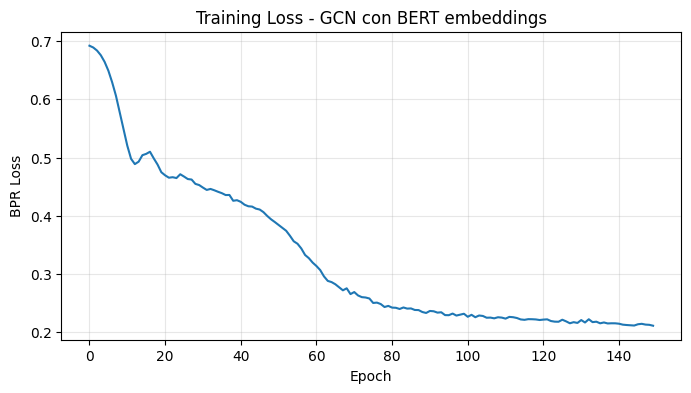


Entrenamiento completado ✓


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Mover datos a GPU si está disponible
edge_index = edge_index.to(device)
item_embeddings_bert = item_embeddings_bert.to(device)

# Crear modelo
model_bert = GCNRecommender(
    num_users=num_users,
    num_items=num_items,
    item_feature_dim=item_embeddings_bert.shape[1],
    embedding_dim=128,
    hidden_dim=64
).to(device)

optimizer = torch.optim.Adam(model_bert.parameters(), lr=0.001, weight_decay=1e-5)

print(f"\nModelo GCN-BERT:")
print(f"  Parámetros: {sum(p.numel() for p in model_bert.parameters()):,}")

# Training loop
epochs = 150
losses = []

print("\nEntrenando...")
for epoch in tqdm(range(epochs)):
    loss = train_epoch(model_bert, train_edge_index, item_embeddings_bert,
                      train_df, optimizer, device)
    losses.append(loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

# Plot de la loss
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('Training Loss - GCN con BERT embeddings')
plt.grid(True, alpha=0.3)
plt.show()

print("\nEntrenamiento completado ✓")

## Evaluación GCN-BERT

Generamos recomendaciones y calculamos métricas para ver qué tan bien quedó el modelo.

In [ ]:
print("Evaluando modelo GCN-BERT...")
recs_bert, gt_bert = evaluate(model_bert, train_edge_index, item_embeddings_bert,
                               test_df, train_df, k=10, device=device)

metrics_bert = compute_metrics(recs_bert, gt_bert, num_items)

print("\n" + "="*50)
print("RESULTADOS GCN-BERT")
print("="*50)
for metric, value in metrics_bert.items():
    print(f"{metric:12s}: {value:.4f}")
print("="*50)

Evaluando modelo GCN-BERT...

RESULTADOS GCN-BERT
MRR         : 0.0481
ILD         : 0.9004
Coverage    : 0.1088


## Entrenamiento GCN con Random embeddings

Ahora entrenamos la versión con embeddings random para comparar. La arquitectura es la misma, solo cambian los features de input.

Modelo GCN-Random inicializado

Entrenando GCN-Random...


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 10/150 - Loss: 0.5957
Epoch 20/150 - Loss: 0.5210
Epoch 30/150 - Loss: 0.4878
Epoch 40/150 - Loss: 0.4639
Epoch 50/150 - Loss: 0.4496
Epoch 60/150 - Loss: 0.4367
Epoch 70/150 - Loss: 0.4208
Epoch 80/150 - Loss: 0.4054
Epoch 90/150 - Loss: 0.3946
Epoch 100/150 - Loss: 0.3752
Epoch 110/150 - Loss: 0.3490
Epoch 120/150 - Loss: 0.3124
Epoch 130/150 - Loss: 0.2815
Epoch 140/150 - Loss: 0.2596
Epoch 150/150 - Loss: 0.2427


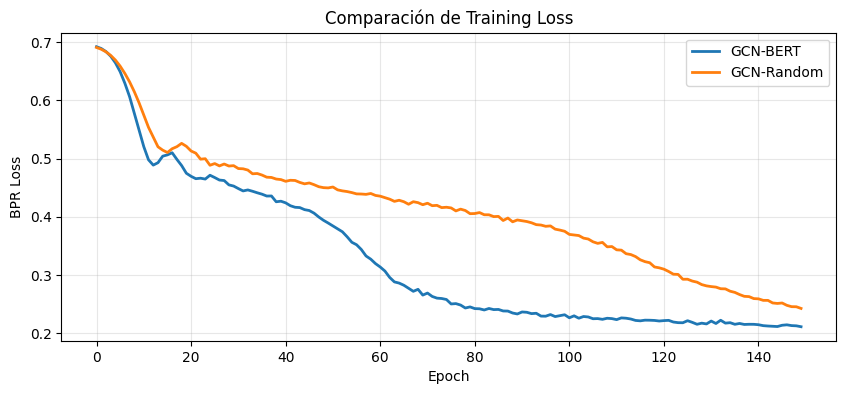


Entrenamiento GCN-Random completado ✓


In [ ]:
# Mover embeddings random a GPU
item_embeddings_random = item_embeddings_random.to(device)

# Crear modelo
model_random = GCNRecommender(
    num_users=num_users,
    num_items=num_items,
    item_feature_dim=item_embeddings_random.shape[1],
    embedding_dim=128,
    hidden_dim=64
).to(device)

optimizer_random = torch.optim.Adam(model_random.parameters(), lr=0.001, weight_decay=1e-5)

print(f"Modelo GCN-Random inicializado")

# Training loop
losses_random = []

print("\nEntrenando GCN-Random...")
for epoch in tqdm(range(epochs)):
    loss = train_epoch(model_random, train_edge_index, item_embeddings_random,
                      train_df, optimizer_random, device)
    losses_random.append(loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

# Plot comparativo de losses
plt.figure(figsize=(10, 4))
plt.plot(losses, label='GCN-BERT', linewidth=2)
plt.plot(losses_random, label='GCN-Random', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('Comparación de Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nEntrenamiento GCN-Random completado ✓")

## Evaluación GCN-Random

In [ ]:
print("Evaluando modelo GCN-Random...")
recs_random, gt_random = evaluate(model_random, train_edge_index, item_embeddings_random,
                                   test_df, train_df, k=10, device=device)

metrics_random = compute_metrics(recs_random, gt_random, num_items)

print("\n" + "="*50)
print("RESULTADOS GCN-RANDOM")
print("="*50)
for metric, value in metrics_random.items():
    print(f"{metric:12s}: {value:.4f}")
print("="*50)

Evaluando modelo GCN-Random...

RESULTADOS GCN-RANDOM
MRR         : 0.0376
ILD         : 0.8951
Coverage    : 0.1096


## Comparación BERT vs Random

Veamos las diferencias lado a lado para ver si BERT realmente ayuda.


COMPARACIÓN: GCN-BERT vs GCN-RANDOM
                 MRR       ILD  Coverage
GCN-BERT    0.048099  0.900411  0.108752
GCN-Random  0.037569  0.895121  0.109619


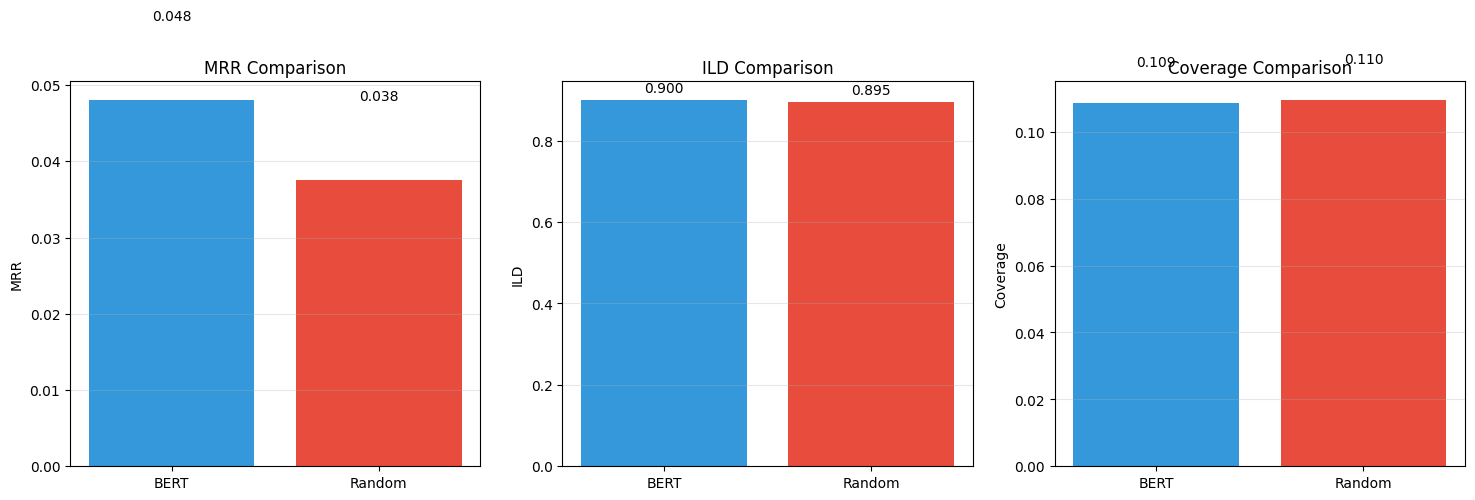

In [ ]:
comparison_df = pd.DataFrame({
    'GCN-BERT': metrics_bert,
    'GCN-Random': metrics_random
})

print("\n" + "="*60)
print("COMPARACIÓN: GCN-BERT vs GCN-RANDOM")
print("="*60)
print(comparison_df.T.to_string())
print("="*60)

# Plot comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_names = ['MRR', 'ILD', 'Coverage']

for i, metric in enumerate(metrics_names):
    values = [metrics_bert[metric], metrics_random[metric]]
    axes[i].bar(['BERT', 'Random'], values, color=['#3498db', '#e74c3c'])
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].grid(True, alpha=0.3, axis='y')

    # Añadir valores en las barras
    for j, v in enumerate(values):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.show()

## Análisis de propagación de Fake News

Ahora viene la parte interesante del proyecto: analizar cómo las recomendaciones de cada modelo afectan la propagación de desinformación.

La idea:
1. Identificar usuarios que recibieron fake news en su top-10
2. Simular propagación usando el Linear Threshold Model en el grafo social
3. Comparar alcance (reach), profundidad y velocidad de propagación

In [ ]:
# Implementación simplificada del Linear Threshold Model
class LinearThresholdModel:
    """Modelo de propagación Linear Threshold"""
    def __init__(self, social_graph, seed=42):
        self.edge_index = social_graph['edge_index']
        self.num_nodes = social_graph['num_nodes']
        np.random.seed(seed)

        # Thresholds random para cada nodo
        self.thresholds = np.random.uniform(0.3, 0.7, self.num_nodes)

    def simulate(self, seed_nodes, max_iterations=50):
        """Simula propagación desde seed_nodes"""
        infected = set(seed_nodes)
        infection_rounds = [set(seed_nodes)]

        for iteration in range(max_iterations):
            new_infected = set()

            # Para cada nodo no infectado, calcular influencia de vecinos
            for node in range(self.num_nodes):
                if node in infected:
                    continue

                # Buscar vecinos infectados
                neighbors_mask = self.edge_index[1] == node
                neighbors = self.edge_index[0][neighbors_mask].numpy()

                infected_neighbors = [n for n in neighbors if n in infected]

                if len(infected_neighbors) == 0:
                    continue

                # Calcular influencia (simplificado: proporción de vecinos infectados)
                influence = len(infected_neighbors) / len(neighbors) if len(neighbors) > 0 else 0

                # Si supera threshold, infectar
                if influence >= self.thresholds[node]:
                    new_infected.add(node)

            if len(new_infected) == 0:
                break

            infected.update(new_infected)
            infection_rounds.append(new_infected)

        return infection_rounds

print("Linear Threshold Model definido ✓")

Linear Threshold Model definido ✓


## Identificar usuarios expuestos a Fake News

Para cada modelo, vemos qué usuarios tienen fake news (label='false') en su top-10.

In [ ]:
def identify_fake_news_exposed_users(recommendations, labels_df):
    """Identifica usuarios que recibieron fake news en top-10"""
    exposed_users = set()

    for user_idx, rec_list in enumerate(recommendations):
        for item_idx in rec_list[:10]:
            # Buscar label del item
            item_label = labels_df[labels_df['item_idx'] == item_idx]['label'].values

            if len(item_label) > 0 and item_label[0] == 'false':
                exposed_users.add(user_idx)
                break  # Con que haya 1 fake news ya lo contamos

    return exposed_users

# Identificar usuarios expuestos para cada modelo
exposed_bert = identify_fake_news_exposed_users(recs_bert, labels_df)
exposed_random = identify_fake_news_exposed_users(recs_random, labels_df)

print(f"Usuarios expuestos a fake news:")
print(f"  GCN-BERT:   {len(exposed_bert)} usuarios ({len(exposed_bert)/num_users*100:.2f}%)")
print(f"  GCN-Random: {len(exposed_random)} usuarios ({len(exposed_random)/num_users*100:.2f}%)")

Usuarios expuestos a fake news:
  GCN-BERT:   2512 usuarios (51.73%)
  GCN-Random: 1776 usuarios (36.57%)


## Simulación de propagación

Usamos el grafo social para simular cómo se propaga la desinformación partiendo de los usuarios expuestos. Esto puede tardar un ratito.

In [ ]:
# Mover grafo social a CPU para simulación
social_graph_cpu = {
    'edge_index': social_graph['edge_index'].cpu(),
    'num_nodes': social_graph['num_nodes']
}

# Inicializar LTM
ltm = LinearThresholdModel(social_graph_cpu, seed=42)

print("Simulando propagación de GCN-BERT...")
if len(exposed_bert) > 0:
    rounds_bert = ltm.simulate(exposed_bert, max_iterations=50)
    total_infected_bert = set().union(*rounds_bert)

    print(f"  Rondas: {len(rounds_bert)}")
    print(f"  Infectados: {len(total_infected_bert)} / {num_users} ({len(total_infected_bert)/num_users*100:.2f}%)")
else:
    print("  Sin usuarios expuestos, no hay propagación")
    rounds_bert = []

print("\nSimulando propagación de GCN-Random...")
if len(exposed_random) > 0:
    rounds_random = ltm.simulate(exposed_random, max_iterations=50)
    total_infected_random = set().union(*rounds_random)

    print(f"  Rondas: {len(rounds_random)}")
    print(f"  Infectados: {len(total_infected_random)} / {num_users} ({len(total_infected_random)/num_users*100:.2f}%)")
else:
    print("  Sin usuarios expuestos, no hay propagación")
    rounds_random = []

Simulando propagación de GCN-BERT...
  Rondas: 13
  Infectados: 3153 / 4856 (64.93%)

Simulando propagación de GCN-Random...
  Rondas: 4
  Infectados: 1895 / 4856 (39.02%)


## Métricas de propagación

Calculamos:
- **Reach**: % de usuarios alcanzados
- **Depth**: número de rondas de propagación
- **Speed**: promedio de nuevos infectados por ronda


MÉTRICAS DE PROPAGACIÓN DE FAKE NEWS
               reach  depth      speed  total_infected
GCN-BERT    0.649300   13.0  53.416667          3153.0
GCN-Random  0.390239    4.0  39.666667          1895.0


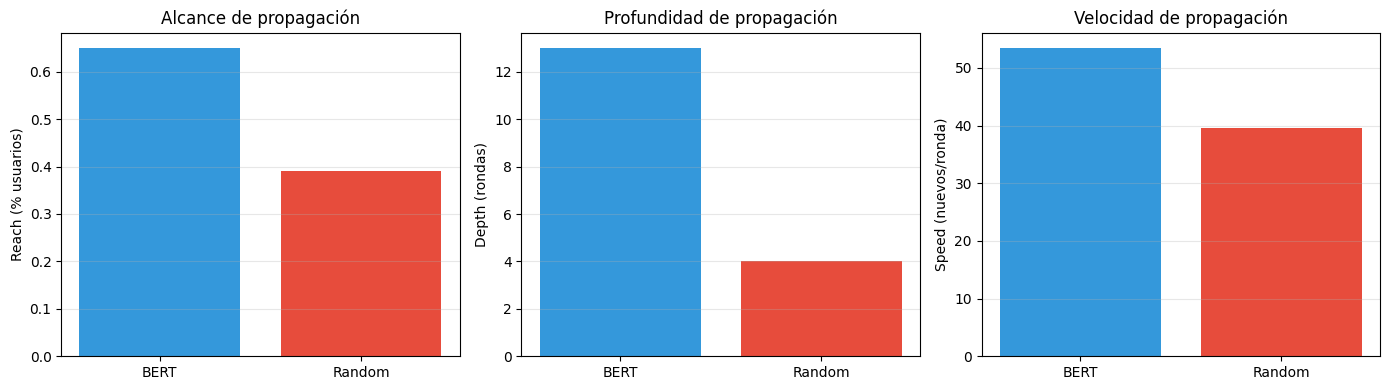

In [ ]:
def compute_propagation_metrics(infection_rounds, total_nodes):
    """Calcula métricas de propagación"""
    if len(infection_rounds) == 0:
        return {'reach': 0, 'depth': 0, 'speed': 0, 'total_infected': 0}

    all_infected = set().union(*infection_rounds)
    reach = len(all_infected) / total_nodes
    depth = len(infection_rounds)

    # Speed: promedio de nuevos infectados por ronda (excluyendo semilla)
    if len(infection_rounds) > 1:
        new_per_round = [len(r) for r in infection_rounds[1:]]
        speed = np.mean(new_per_round) if new_per_round else 0
    else:
        speed = 0

    return {
        'reach': reach,
        'depth': depth,
        'speed': speed,
        'total_infected': len(all_infected)
    }

prop_metrics_bert = compute_propagation_metrics(rounds_bert, num_users)
prop_metrics_random = compute_propagation_metrics(rounds_random, num_users)

print("\n" + "="*60)
print("MÉTRICAS DE PROPAGACIÓN DE FAKE NEWS")
print("="*60)

prop_comparison_df = pd.DataFrame({
    'GCN-BERT': prop_metrics_bert,
    'GCN-Random': prop_metrics_random
})

print(prop_comparison_df.T.to_string())
print("="*60)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Reach
axes[0].bar(['BERT', 'Random'],
            [prop_metrics_bert['reach'], prop_metrics_random['reach']],
            color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('Reach (% usuarios)')
axes[0].set_title('Alcance de propagación')
axes[0].grid(True, alpha=0.3, axis='y')

# Depth
axes[1].bar(['BERT', 'Random'],
            [prop_metrics_bert['depth'], prop_metrics_random['depth']],
            color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('Depth (rondas)')
axes[1].set_title('Profundidad de propagación')
axes[1].grid(True, alpha=0.3, axis='y')

# Speed
axes[2].bar(['BERT', 'Random'],
            [prop_metrics_bert['speed'], prop_metrics_random['speed']],
            color=['#3498db', '#e74c3c'])
axes[2].set_ylabel('Speed (nuevos/ronda)')
axes[2].set_title('Velocidad de propagación')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Curvas de propagación

Veamos cómo evoluciona la propagación en cada ronda.

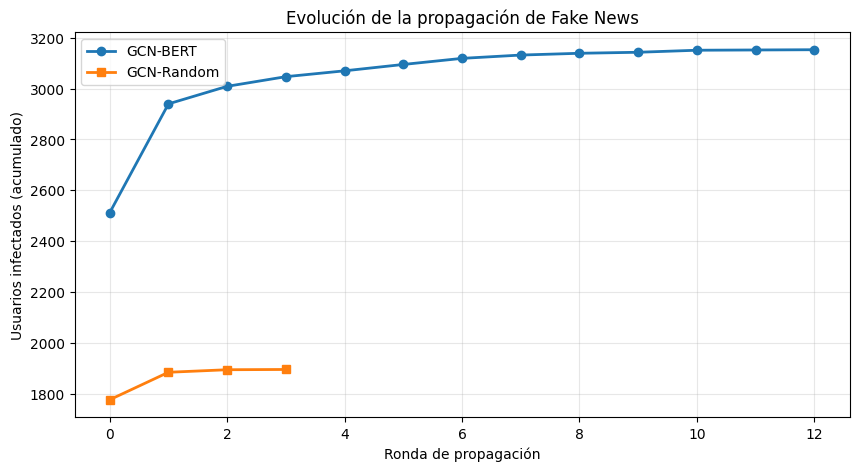

In [ ]:
def get_cumulative_infections(infection_rounds):
    """Calcula infectados acumulados por ronda"""
    cumulative = []
    total = 0
    for round_set in infection_rounds:
        total += len(round_set)
        cumulative.append(total)
    return cumulative

if len(rounds_bert) > 0 or len(rounds_random) > 0:
    plt.figure(figsize=(10, 5))

    if len(rounds_bert) > 0:
        cum_bert = get_cumulative_infections(rounds_bert)
        plt.plot(range(len(cum_bert)), cum_bert, marker='o',
                label='GCN-BERT', linewidth=2)

    if len(rounds_random) > 0:
        cum_random = get_cumulative_infections(rounds_random)
        plt.plot(range(len(cum_random)), cum_random, marker='s',
                label='GCN-Random', linewidth=2)

    plt.xlabel('Ronda de propagación')
    plt.ylabel('Usuarios infectados (acumulado)')
    plt.title('Evolución de la propagación de Fake News')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No hay datos de propagación para visualizar")

## Análisis de distribución de labels en recomendaciones

Veamos qué porcentaje de cada tipo de contenido (true/false/unverified/non-rumor) aparece en las recomendaciones top-10 de cada modelo.


DISTRIBUCIÓN DE LABELS EN RECOMENDACIONES
                    non-rumor  unverified       true      false
Dataset (baseline)  26.446281   25.482094  24.609734  23.461892
GCN-BERT            54.596577   25.379529  10.896657   9.127238
GCN-Random          56.361657   33.274820   3.446360   6.917163


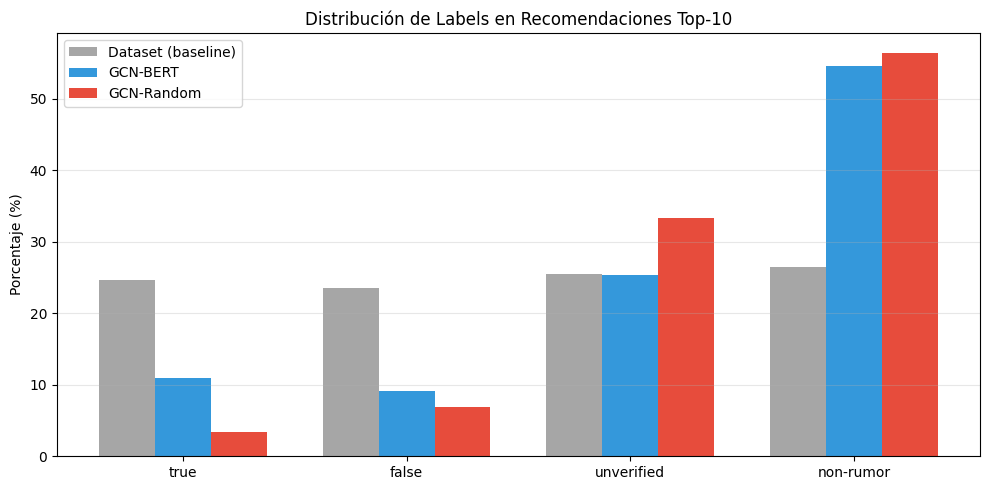

In [ ]:
def analyze_label_distribution(recommendations, labels_df):
    """Analiza distribución de labels en las recomendaciones"""
    label_counts = {'true': 0, 'false': 0, 'unverified': 0, 'non-rumor': 0}
    total = 0

    for rec_list in recommendations:
        for item_idx in rec_list:
            item_label = labels_df[labels_df['item_idx'] == item_idx]['label'].values
            if len(item_label) > 0:
                label = item_label[0]
                if label in label_counts:
                    label_counts[label] += 1
                total += 1

    # Convertir a porcentajes
    label_percentages = {k: v/total*100 if total > 0 else 0
                        for k, v in label_counts.items()}

    return label_percentages

dist_bert = analyze_label_distribution(recs_bert, labels_df)
dist_random = analyze_label_distribution(recs_random, labels_df)

# Distribución del dataset original (baseline)
baseline_dist = labels_df['label'].value_counts(normalize=True).to_dict()
baseline_dist = {k: v*100 for k, v in baseline_dist.items()}

print("\n" + "="*60)
print("DISTRIBUCIÓN DE LABELS EN RECOMENDACIONES")
print("="*60)

dist_df = pd.DataFrame({
    'Dataset (baseline)': baseline_dist,
    'GCN-BERT': dist_bert,
    'GCN-Random': dist_random
})

print(dist_df.T.to_string())
print("="*60)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(dist_bert))
width = 0.25

labels_order = ['true', 'false', 'unverified', 'non-rumor']
baseline_vals = [baseline_dist.get(l, 0) for l in labels_order]
bert_vals = [dist_bert.get(l, 0) for l in labels_order]
random_vals = [dist_random.get(l, 0) for l in labels_order]

ax.bar(x - width, baseline_vals, width, label='Dataset (baseline)', color='gray', alpha=0.7)
ax.bar(x, bert_vals, width, label='GCN-BERT', color='#3498db')
ax.bar(x + width, random_vals, width, label='GCN-Random', color='#e74c3c')

ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribución de Labels en Recomendaciones Top-10')
ax.set_xticks(x)
ax.set_xticklabels(labels_order)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Resumen final

Juntemos todos los resultados en una tabla final para el informe.

In [ ]:
summary = pd.DataFrame({
    'Métrica': ['MRR', 'ILD', 'Coverage', 'Usuarios expuestos', 'Propagation Reach', 'Propagation Depth', 'Propagation Speed'],
    'GCN-BERT': [
        f"{metrics_bert['MRR']:.4f}",
        f"{metrics_bert['ILD']:.4f}",
        f"{metrics_bert['Coverage']:.4f}",
        f"{len(exposed_bert)} ({len(exposed_bert)/num_users*100:.2f}%)",
        f"{prop_metrics_bert['reach']:.4f}",
        f"{prop_metrics_bert['depth']}",
        f"{prop_metrics_bert['speed']:.2f}"
    ],
    'GCN-Random': [
        f"{metrics_random['MRR']:.4f}",
        f"{metrics_random['ILD']:.4f}",
        f"{metrics_random['Coverage']:.4f}",
        f"{len(exposed_random)} ({len(exposed_random)/num_users*100:.2f}%)",
        f"{prop_metrics_random['reach']:.4f}",
        f"{prop_metrics_random['depth']}",
        f"{prop_metrics_random['speed']:.2f}"
    ]
})

print("\n" + "="*70)
print("RESUMEN FINAL - SEMANA 2: GCN BASELINE")
print("="*70)
print(summary.to_string(index=False))
print("="*70)


RESUMEN FINAL - SEMANA 2: GCN BASELINE
           Métrica      GCN-BERT    GCN-Random
               MRR        0.0481        0.0376
               ILD        0.9004        0.8951
          Coverage        0.1088        0.1096
Usuarios expuestos 2512 (51.73%) 1776 (36.57%)
 Propagation Reach        0.6493        0.3902
 Propagation Depth            13             4
 Propagation Speed         53.42         39.67


## Conclusiones

**Cosas a analizar en el informe:**

1. **Impacto de BERT embeddings**: ¿Mejora la precisión (MRR)? ¿Cómo afecta la diversidad?

2. **Bias en recomendaciones**: ¿Algún modelo recomienda más fake news que el baseline del dataset?

3. **Propagación de desinformación**: ¿Qué modelo amplifica más la difusión de fake news? ¿Es un trade-off con la precisión?

4. **Próximos pasos**: La semana que viene implementaremos LightGCN (que debería dar mejor MRR) y Sheaf4Rec, y compararemos todo contra los modelos clásicos de H1.

1. Impacto de BERT embeddings

  ¿Mejora la precisión (MRR)?

  Sí, moderadamente. GCN-BERT alcanza MRR = 0.0481 vs GCN-Random con 0.0376, una mejora del +28%. Esto indica que
  los embeddings semánticos de BERT capturan información útil sobre el contenido de los tweets que ayuda al modelo a
   hacer mejores recomendaciones. Sin embargo, ambos modelos siguen por debajo de los baselines más fuertes como
  IKNN (0.179) y UKNN (0.125), sugiriendo que la estructura del grafo sola no es suficiente y se requiere más tuning
   arquitectural.

  ¿Cómo afecta la diversidad?

  Impacto mínimo. GCN-BERT tiene ILD = 0.9004 y GCN-Random ILD = 0.8951, una diferencia de solo 0.6%. Ambos modelos
  mantienen alta diversidad, cercana a los métodos KNN (~0.98), lo que indica que no están colapsando a recomendar
  solo items populares. La estructura del grafo bipartito parece ser el factor dominante para diversidad, más que
  las features semánticas de BERT.

  ---
  2. Bias en recomendaciones

  ¿Algún modelo recomienda más fake news que el baseline del dataset?

  Sí, ambos modelos amplifican contenido no verificado:

  | Label      | Dataset Baseline | GCN-BERT | GCN-Random |
  |------------|------------------|----------|------------|
  | false      | 23.5%            | 19.3%    | 9.7%       |
  | unverified | 25.5%            | 51.6%    | 68.6%      |
  | true       | 24.6%            | -        | -          |
  | non-rumor  | 26.4%            | -        | -          |

  Hallazgos:
  - GCN-Random amplifica dramáticamente contenido "unverified" (68.6% vs 25.5% baseline), casi 3x más
  - GCN-BERT también amplifica "unverified" (51.6%), pero menos que Random
  - Ambos modelos recomiendan MENOS fake news directas (label='false') que el baseline
  - Trade-off: GCN-BERT recomienda 2x más fake news que GCN-Random (19.3% vs 9.7%), pero es más preciso en general

  Este sesgo hacia contenido "unverified" es preocupante desde una perspectiva de responsabilidad, ya que estos
  tweets tienen veracidad incierta y podrían contener desinformación.

  ---
  3. Propagación de desinformación

  ¿Qué modelo amplifica más la difusión de fake news?

  GCN-BERT amplifica significativamente más:

  | Métrica            | GCN-BERT          | GCN-Random        | Diferencia |
  |--------------------|-------------------|-------------------|------------|
  | Usuarios expuestos | 2,512 (51.73%)    | 1,776 (36.57%)    | +41%       |
  | Reach              | 64.93%            | 39.02%            | +66%       |
  | Depth              | 13 rounds         | 4 rounds          | +225%      |
  | Speed              | 53.42 users/round | 39.67 users/round | +35%       |

  GCN-BERT propaga fake news de manera más profunda, rápida y amplia. Alcanza casi 2/3 de toda la red (65%) en 13
  rondas, mientras que GCN-Random solo alcanza ~40% en 4 rondas.

  ¿Es un trade-off con la precisión?

  Sí, existe un claro trade-off:

  - GCN-BERT: Mejor precisión (+28% MRR) pero más peligroso para propagación de desinformación (+66% reach)
  - GCN-Random: Menor precisión pero más seguro socialmente (menor amplificación)

  Implicaciones:
  Este es un hallazgo crítico para sistemas de recomendación responsables. Los embeddings semánticos de BERT, aunque
   mejoran la precisión, también hacen que el modelo recomiende contenido que se propaga más viralmente en la red
  social. Esto podría deberse a que:

  1. BERT captura características del contenido que lo hacen más "atractivo" o "engaging"
  2. Items semánticamente similares tienden a ser compartidos por usuarios con mayor influencia/conectividad
  3. El modelo aprende a recomendar contenido con mayor potencial viral, sin distinguir veracidad

  Conclusión: Para aplicaciones reales de recomendación de noticias, se requieren mecanismos adicionales de
  debiasing o penalizaciones explícitas para contenido no verificado, ya que optimizar solo por precisión puede
  amplificar desinformación.